<a href="https://colab.research.google.com/github/sadhika-tech/deep-learning-lab/blob/main/Lab%205/comprehensive_study_of_cnn_hyperparameters_cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import os

OUT_DIR = "/kaggle/working/results"
os.makedirs(OUT_DIR, exist_ok=True)


In [ ]:
import time
import gc
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

tf.random.set_seed(7)
np.random.seed(7)


In [ ]:
IMG_SIZE = (224, 224)
NUM_CLASSES = 37
BATCH = 32

data, ds_info = tfds.load("oxford_iiit_pet", with_info=True, as_supervised=True)
print("Available splits:", list(data.keys()))

raw_train = data["train"]
raw_test = data["test"]

TOTAL_TRAIN = ds_info.splits["train"].num_examples
raw_train = raw_train.shuffle(buffer_size=TOTAL_TRAIN, seed=7, reshuffle_each_iteration=False)

VAL_FRACTION = 0.20
n_val = int(TOTAL_TRAIN * VAL_FRACTION)
n_train = TOTAL_TRAIN - n_val
print(f"Train examples: {n_train}, Val examples: {n_val}")

def prep(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = preprocess_input(image)
    return image, label

train_raw = raw_train.skip(n_val)
val_raw = raw_train.take(n_val)

train_ds = train_raw.map(prep, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_raw.map(prep, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = raw_test.map(prep, num_parallel_calls=tf.data.AUTOTUNE)

train_ds_b = train_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
val_ds_b = val_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
test_ds_b = test_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)


I0000 00:00:1788082828.445080   24757 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788082828.448476   24757 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Available splits: ['train', 'test']
Train examples: 2944, Val examples: 736


In [ ]:
def mobilenet_backbone():
    """Frozen ImageNet MobileNetV2 feature extractor + GAP head."""
    backbone = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
    backbone.trainable = False
    inp = layers.Input(shape=(224, 224, 3))
    feat = backbone(inp, training=False)
    feat = layers.GlobalAveragePooling2D()(feat)
    return inp, feat, backbone


In [ ]:
def build_init_model(init_scheme):
    inp, feat, _ = mobilenet_backbone()
    x = layers.Dense(256, activation="relu", kernel_initializer=init_scheme)(feat)
    out = layers.Dense(NUM_CLASSES, activation="softmax", kernel_initializer=init_scheme)(x)
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

EPOCHS_STAGE1 = 5

init_schemes = {
    "Zero":   tf.keras.initializers.Zeros(),
    "Random": tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.02),
    "Xavier": tf.keras.initializers.GlorotUniform(seed=7),
    "He":     tf.keras.initializers.HeNormal(seed=7)
}

init_histories = {}
for tag, scheme in init_schemes.items():
    print(f"[Init] training with {tag} initialization")
    m = build_init_model(scheme)
    h = m.fit(train_ds_b, validation_data=val_ds_b, epochs=EPOCHS_STAGE1, verbose=1)
    init_histories[tag] = h.history
    del m
    tf.keras.backend.clear_session(); gc.collect()


[Init] training with Zero initialization
Epoch 1/5


2026-08-30 09:40:49.949073: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 09:40:50.086658: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1788082851.975475   24828 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 126ms/step - accuracy: 0.0251 - loss: 3.6113 - val_accuracy: 0.0177 - val_loss: 3.6120
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.0296 - loss: 3.6109 - val_accuracy: 0.0177 - val_loss: 3.6131
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.0272 - loss: 3.6107 - val_accuracy: 0.0177 - val_loss: 3.6141
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.0275 - loss: 3.6105 - val_accuracy: 0.0177 - val_loss: 3.6151
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.0268 - loss: 3.6103 - val_accuracy: 0.0149 - val_loss: 3.6160
[Init] training with Random initialization
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 125ms/step - accuracy: 0.7069 - loss: 1.2357 - val_accuracy: 0.8832 - val_loss: 0.4033
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.9202 - loss: 0.2651 - val_accuracy: 0.8899 - val_loss: 0.3448
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.9531 - loss

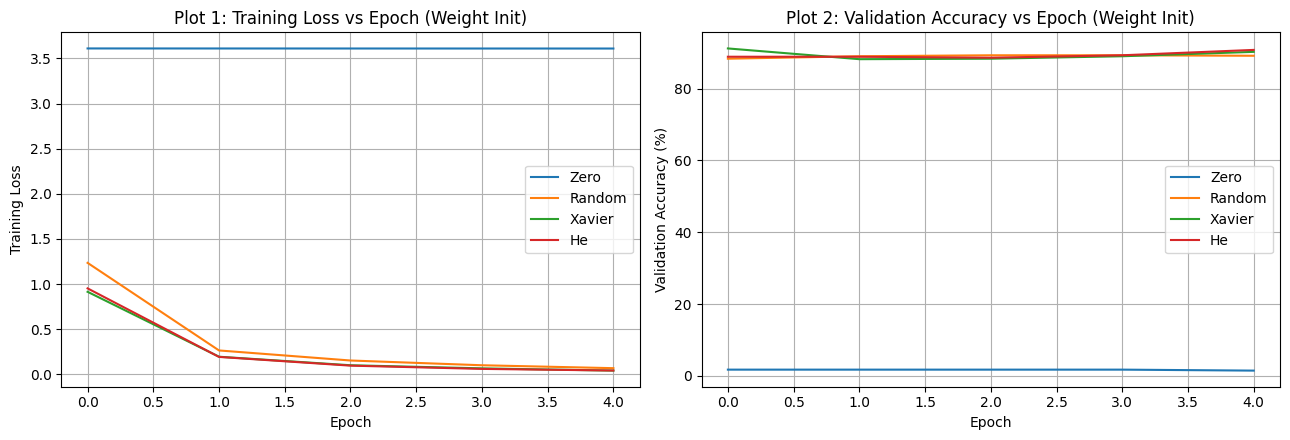

Scheme   | Final Train Loss  | Final Val Acc
Zero     |            3.6103 |         1.49%
Random   |            0.0687 |        89.13%
Xavier   |            0.0417 |        90.22%
He       |            0.0427 |        90.76%


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

for tag, hist in init_histories.items():
    ax[0].plot(hist["loss"], label=tag)
ax[0].set_title("Plot 1: Training Loss vs Epoch (Weight Init)")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Training Loss"); ax[0].legend(); ax[0].grid(True)

for tag, hist in init_histories.items():
    ax[1].plot(np.array(hist["val_accuracy"]) * 100, label=tag)
ax[1].set_title("Plot 2: Validation Accuracy vs Epoch (Weight Init)")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Validation Accuracy (%)"); ax[1].legend(); ax[1].grid(True)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/plot1_2_weight_init.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"{'Scheme':8s} | {'Final Train Loss':17s} | {'Final Val Acc':13s}")
for tag, hist in init_histories.items():
    print(f"{tag:8s} | {hist['loss'][-1]:17.4f} | {hist['val_accuracy'][-1]*100:12.2f}%")


In [ ]:
def build_reg_model(dropout_rate=0.0, l2_lambda=0.0):
    inp, feat, _ = mobilenet_backbone()
    x = layers.Dense(256, activation="relu",
                      kernel_regularizer=l2(l2_lambda) if l2_lambda > 0 else None)(feat)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

reg_setups = {
    "No Regularization": dict(dropout_rate=0.0, l2_lambda=0.0),
    "L2 Only":            dict(dropout_rate=0.0, l2_lambda=0.02),
    "Dropout Only":       dict(dropout_rate=0.4, l2_lambda=0.0),
}

reg_histories = {}
for tag, kw in reg_setups.items():
    print(f"[Reg] training: {tag}")
    m = build_reg_model(**kw)
    h = m.fit(train_ds_b, validation_data=val_ds_b, epochs=EPOCHS_STAGE1, verbose=1)
    reg_histories[tag] = h.history
    del m
    tf.keras.backend.clear_session(); gc.collect()


[Reg] training: No Regularization
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 127ms/step - accuracy: 0.7683 - loss: 0.8837 - val_accuracy: 0.8967 - val_loss: 0.3332
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.9399 - loss: 0.1855 - val_accuracy: 0.8736 - val_loss: 0.3521
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.9732 - loss: 0.0968 - val_accuracy: 0.8872 - val_loss: 0.3637
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.9837 - loss: 0.0563 - val_accuracy: 0.8832 - val_loss: 0.4047
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9901 - loss: 0.0417 - val_accuracy: 0.8899 - val_loss: 0.3498
[Reg] training: L2 Only
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 129ms/step - accuracy: 0.7459 - loss: 5.6389 - val_accuracy: 0.8832 - val_loss: 2.4931
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9178 - loss: 1.5356 - val_accuracy: 0.8832 - val_loss: 1.0830
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step 

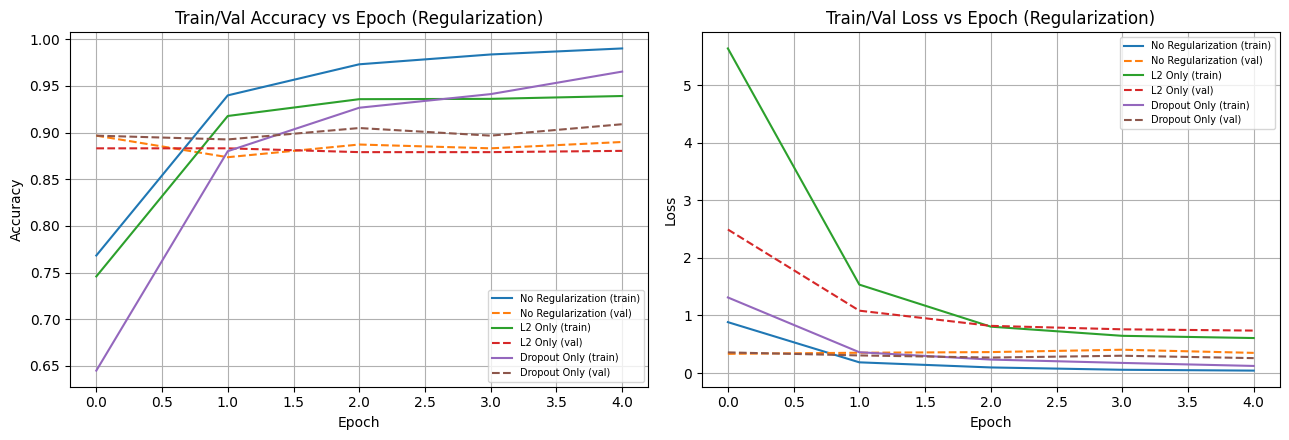

No Regularization  | train_acc= 99.01% | val_acc= 88.99% | gen. gap=10.02pp
L2 Only            | train_acc= 93.92% | val_acc= 88.04% | gen. gap= 5.88pp
Dropout Only       | train_acc= 96.54% | val_acc= 90.90% | gen. gap= 5.64pp


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

for tag, hist in reg_histories.items():
    ax[0].plot(hist["accuracy"], label=f"{tag} (train)")
    ax[0].plot(hist["val_accuracy"], linestyle="--", label=f"{tag} (val)")
ax[0].set_title("Train/Val Accuracy vs Epoch (Regularization)")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Accuracy"); ax[0].legend(fontsize=7); ax[0].grid(True)

for tag, hist in reg_histories.items():
    ax[1].plot(hist["loss"], label=f"{tag} (train)")
    ax[1].plot(hist["val_loss"], linestyle="--", label=f"{tag} (val)")
ax[1].set_title("Train/Val Loss vs Epoch (Regularization)")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Loss"); ax[1].legend(fontsize=7); ax[1].grid(True)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/plot3_4_regularization.png", dpi=200, bbox_inches="tight")
plt.show()

for tag, hist in reg_histories.items():
    gap = hist["accuracy"][-1] - hist["val_accuracy"][-1]
    print(f"{tag:18s} | train_acc={hist['accuracy'][-1]*100:6.2f}% | val_acc={hist['val_accuracy'][-1]*100:6.2f}% | gen. gap={gap*100:5.2f}pp")


In [ ]:
# Quick numeric illustration of BatchNorm on a toy vector (matches the worked example in the report)
toy = np.array([3.0, 5.0, 7.0, 9.0])
mu = toy.mean()
var = toy.var()
normed = (toy - mu) / np.sqrt(var + 1e-8)
print("toy batch     :", toy)
print("batch mean    :", mu)
print("batch variance:", var)
print("normalized    :", np.round(normed, 3))


toy batch     : [3. 5. 7. 9.]
batch mean    : 6.0
batch variance: 5.0
normalized    : [-1.342 -0.447  0.447  1.342]


In [ ]:
def build_bn_model(use_bn):
    inp, feat, _ = mobilenet_backbone()
    x = layers.Dense(256, activation=None)(feat)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

bn_setups = {"Without BatchNorm": False, "With BatchNorm": True}
bn_histories = {}
for tag, flag in bn_setups.items():
    print(f"[BN] training: {tag}")
    m = build_bn_model(flag)
    h = m.fit(train_ds_b, validation_data=val_ds_b, epochs=EPOCHS_STAGE1, verbose=1)
    bn_histories[tag] = h.history
    del m
    tf.keras.backend.clear_session(); gc.collect()


[BN] training: Without BatchNorm
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 128ms/step - accuracy: 0.7619 - loss: 0.9096 - val_accuracy: 0.8981 - val_loss: 0.3358
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9402 - loss: 0.1843 - val_accuracy: 0.8886 - val_loss: 0.3270
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9745 - loss: 0.0927 - val_accuracy: 0.9008 - val_loss: 0.3153
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.9834 - loss: 0.0656 - val_accuracy: 0.8913 - val_loss: 0.3567
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.9905 - loss: 0.0414 - val_accuracy: 0.8940 - val_loss: 0.3687
[BN] training: With BatchNorm
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 127ms/step - accuracy: 0.7874 - loss: 0.8515 - val_accuracy: 0.8845 - val_loss: 0.3665
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9684 - loss: 0.1553 - val_accuracy: 0.9076 - val_loss: 0.2873
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/

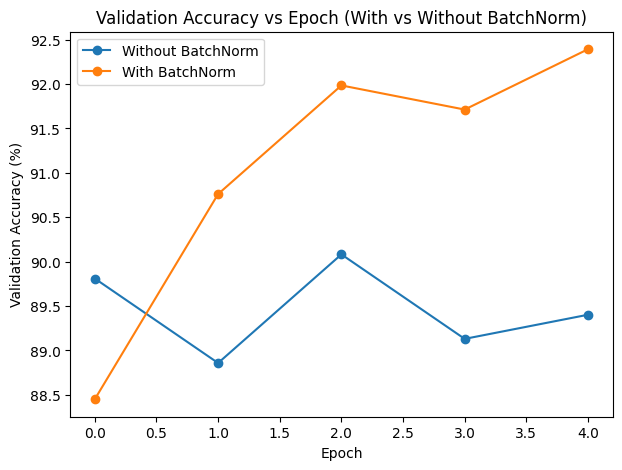

In [ ]:
plt.figure(figsize=(7, 5))
for tag, hist in bn_histories.items():
    plt.plot(np.array(hist["val_accuracy"]) * 100, marker="o", label=tag)
plt.title("Validation Accuracy vs Epoch (With vs Without BatchNorm)")
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy (%)")
plt.legend()
plt.savefig(f"{OUT_DIR}/plot5_batchnorm.png", dpi=200, bbox_inches="tight")
plt.show()


In [ ]:
def build_optim_model(optimizer):
    inp, feat, _ = mobilenet_backbone()
    x = layers.Dense(256, activation="relu")(feat)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = models.Model(inp, out)
    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

optim_setups = {
    "SGD":      tf.keras.optimizers.SGD(learning_rate=0.01),
    "Momentum": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "RMSProp":  tf.keras.optimizers.RMSprop(learning_rate=0.001),
    "Adam":     tf.keras.optimizers.Adam(learning_rate=0.001),
}

optim_histories = {}
optim_stats = {}
for tag, opt in optim_setups.items():
    print(f"[Optim] training: {tag}")
    m = build_optim_model(opt)
    t0 = time.time()
    h = m.fit(train_ds_b, validation_data=val_ds_b, epochs=EPOCHS_STAGE1, verbose=1)
    dt = time.time() - t0
    optim_histories[tag] = h.history
    va = h.history["val_accuracy"]
    optim_stats[tag] = {
        "final_loss": h.history["loss"][-1],
        "best_val_acc": max(va) * 100,
        "epoch_to_converge": int(np.argmax(va)) + 1,
        "time_sec": dt,
    }
    del m
    tf.keras.backend.clear_session(); gc.collect()


[Optim] training: SGD
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 128ms/step - accuracy: 0.3465 - loss: 2.7984 - val_accuracy: 0.6590 - val_loss: 1.9179
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.7918 - loss: 1.3230 - val_accuracy: 0.8166 - val_loss: 0.9898
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.8723 - loss: 0.7431 - val_accuracy: 0.8587 - val_loss: 0.6821
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.8964 - loss: 0.5291 - val_accuracy: 0.8764 - val_loss: 0.5493
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.9127 - loss: 0.4219 - val_accuracy: 0.8750 - val_loss: 0.4771
[Optim] training: Momentum
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 128ms/step - accuracy: 0.6990 - loss: 1.1891 - val_accuracy: 0.8845 - val_loss: 0.3650
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9202 - loss: 0.2512 - val_accuracy: 0.8899 - val_loss: 0.3562
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accurac

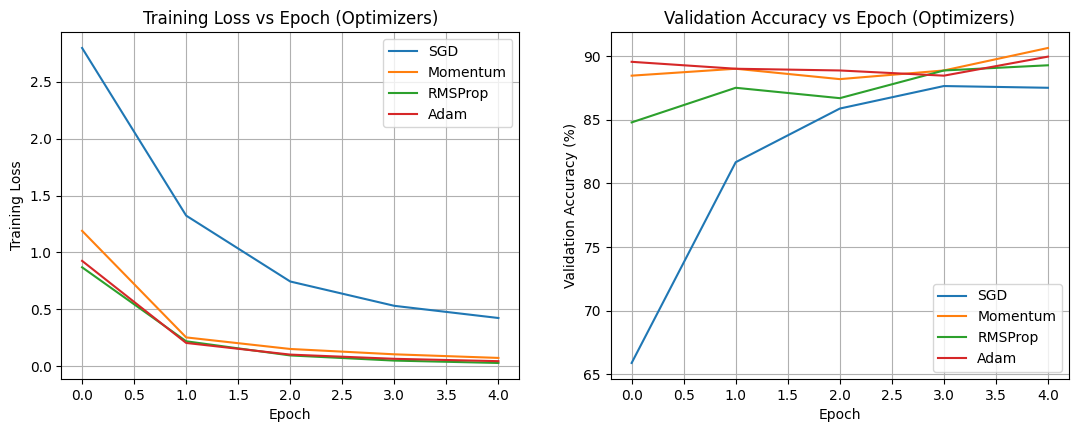

Optimizer | Final Loss | Best Val Acc | Conv. Epoch | Time(s)
SGD       |     0.4219 |       87.64% |           4 |    66.4
Momentum  |     0.0706 |       90.62% |           5 |    65.2
RMSProp   |     0.0262 |       89.27% |           5 |    64.5
Adam      |     0.0420 |       89.95% |           5 |    65.4


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

for tag, hist in optim_histories.items():
    ax[0].plot(hist["loss"], label=tag)
ax[0].set_title("Training Loss vs Epoch (Optimizers)")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Training Loss"); ax[0].legend(); ax[0].grid(True)

for tag, hist in optim_histories.items():
    ax[1].plot(np.array(hist["val_accuracy"]) * 100, label=tag)
ax[1].set_title("Validation Accuracy vs Epoch (Optimizers)")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Validation Accuracy (%)"); ax[1].legend(); ax[1].grid(True)

plt.savefig(f"{OUT_DIR}/plot6_7_optimizers.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"{'Optimizer':9s} | {'Final Loss':10s} | {'Best Val Acc':12s} | {'Conv. Epoch':11s} | {'Time(s)':7s}")
for tag, s in optim_stats.items():
    print(f"{tag:9s} | {s['final_loss']:10.4f} | {s['best_val_acc']:11.2f}% | {s['epoch_to_converge']:11d} | {s['time_sec']:7.1f}")


In [ ]:
def build_hp_model(dropout_rate=0.0, lr=0.001, optimizer_name="adam"):
    inp, feat, _ = mobilenet_backbone()
    x = layers.Dense(256, activation="relu")(feat)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = models.Model(inp, out)
    opt = tf.keras.optimizers.Adam(learning_rate=lr) if optimizer_name == "adam" else tf.keras.optimizers.SGD(learning_rate=lr)
    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


Learning rate: 0.001
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 126ms/step - accuracy: 0.7531 - loss: 0.9164 - val_accuracy: 0.8967 - val_loss: 0.3476
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.9372 - loss: 0.1894 - val_accuracy: 0.8859 - val_loss: 0.3422
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9735 - loss: 0.0980 - val_accuracy: 0.8777 - val_loss: 0.3760
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9834 - loss: 0.0633 - val_accuracy: 0.8723 - val_loss: 0.4409
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9908 - loss: 0.0409 - val_accuracy: 0.9171 - val_loss: 0.2987
Learning rate: 0.0001
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 128ms/step - accuracy: 0.3685 - loss: 2.8175 - val_accuracy: 0.7038 - val_loss: 1.8047
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.8173 - loss: 1.1409 - val_accuracy: 0.8587 - val_loss: 0.7825
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.8

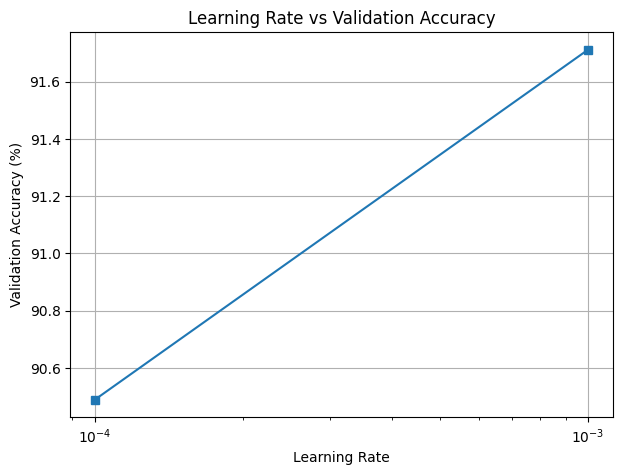

In [ ]:
# Learning rate
lr_grid = [0.001, 0.0001]
lr_scores = {}
for lr in lr_grid:
    print("Learning rate:", lr)
    m = build_hp_model(lr=lr)
    h = m.fit(train_ds_b, validation_data=val_ds_b, epochs=EPOCHS_STAGE1, verbose=1)
    lr_scores[lr] = max(h.history["val_accuracy"]) * 100
    del m; tf.keras.backend.clear_session(); gc.collect()

plt.figure(figsize=(7, 5))
plt.plot(list(lr_scores.keys()), list(lr_scores.values()), marker="s")
plt.xscale("log")
plt.title("Learning Rate vs Validation Accuracy")
plt.xlabel("Learning Rate"); plt.ylabel("Validation Accuracy (%)")
plt.grid(True)
plt.savefig(f"{OUT_DIR}/plot8_learning_rate.png", dpi=200, bbox_inches="tight")
plt.show()


Batch size: 16
Epoch 1/5


2026-08-30 09:58:05.806415: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 09:58:05.944554: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 09:58:06.081015: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


184/184 ━━━━━━━━━━━━━━━━━━━━ 31s 67ms/step - accuracy: 0.7779 - loss: 0.8137 - val_accuracy: 0.8818 - val_loss: 0.3440
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.9487 - loss: 0.1675 - val_accuracy: 0.9035 - val_loss: 0.2955
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.9817 - loss: 0.0740 - val_accuracy: 0.8967 - val_loss: 0.2908
Epoch 4/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.9912 - loss: 0.0407 - val_accuracy: 0.9035 - val_loss: 0.3061
Epoch 5/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.9949 - loss: 0.0264 - val_accuracy: 0.9035 - val_loss: 0.3454
Batch size: 32
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 126ms/step - accuracy: 0.7429 - loss: 0.9240 - val_accuracy: 0.8804 - val_loss: 0.3635
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9338 - loss: 0.2004 - val_accuracy: 0.8913 - val_loss: 0.3363
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9752 - loss: 0.0972 - val_accu

2026-08-30 10:00:35.811980: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 10:00:35.952270: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


46/46 ━━━━━━━━━━━━━━━━━━━━ 36s 321ms/step - accuracy: 0.7167 - loss: 1.1252 - val_accuracy: 0.8668 - val_loss: 0.3878
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 148ms/step - accuracy: 0.9314 - loss: 0.2197 - val_accuracy: 0.8913 - val_loss: 0.3209
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.9715 - loss: 0.1119 - val_accuracy: 0.9130 - val_loss: 0.2697
Epoch 4/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step - accuracy: 0.9888 - loss: 0.0658 - val_accuracy: 0.9198 - val_loss: 0.2549
Epoch 5/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - accuracy: 0.9922 - loss: 0.0460 - val_accuracy: 0.9198 - val_loss: 0.2419


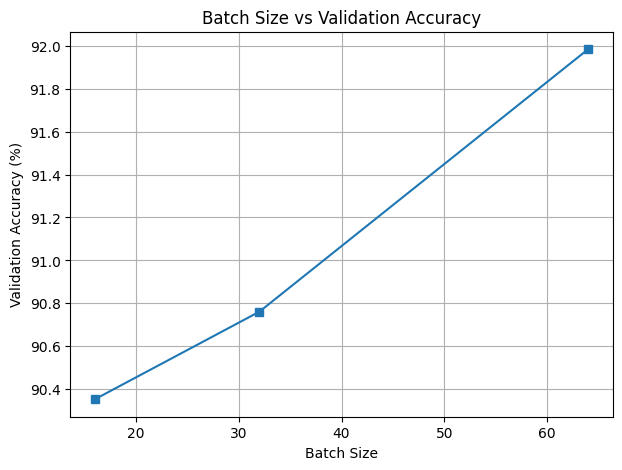

In [ ]:
# Batch size
train_unbatched = train_ds
val_unbatched = val_ds

def rebatch(ds, bs):
    return ds.batch(bs).prefetch(tf.data.AUTOTUNE)

bs_grid = [16, 32, 64]
bs_scores = {}
for bs in bs_grid:
    print("Batch size:", bs)
    m = build_hp_model()
    h = m.fit(rebatch(train_unbatched, bs), validation_data=rebatch(val_unbatched, bs),
              epochs=EPOCHS_STAGE1, verbose=1)
    bs_scores[bs] = max(h.history["val_accuracy"]) * 100
    del m; tf.keras.backend.clear_session(); gc.collect()

plt.figure(figsize=(7, 5))
plt.plot(list(bs_scores.keys()), list(bs_scores.values()), marker="s")
plt.title("Batch Size vs Validation Accuracy")
plt.xlabel("Batch Size"); plt.ylabel("Validation Accuracy (%)")
plt.grid(True)
plt.savefig(f"{OUT_DIR}/plot9_batch_size.png", dpi=200, bbox_inches="tight")
plt.show()


Dropout rate: 0.0
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 126ms/step - accuracy: 0.7571 - loss: 0.9066 - val_accuracy: 0.8913 - val_loss: 0.3567
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.9402 - loss: 0.1860 - val_accuracy: 0.8886 - val_loss: 0.3284
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.9749 - loss: 0.0898 - val_accuracy: 0.8859 - val_loss: 0.3501
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.9864 - loss: 0.0575 - val_accuracy: 0.8723 - val_loss: 0.4031
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.9895 - loss: 0.0442 - val_accuracy: 0.9035 - val_loss: 0.3225
Dropout rate: 0.25
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 126ms/step - accuracy: 0.7018 - loss: 1.0740 - val_accuracy: 0.8913 - val_loss: 0.3656
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.9120 - loss: 0.2686 - val_accuracy: 0.8913 - val_loss: 0.3196
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.9467 - 

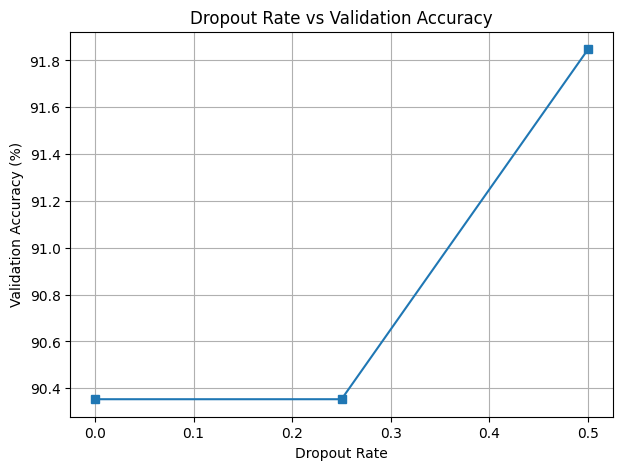

In [ ]:
# Dropout rate
dropout_grid = [0.0, 0.25, 0.5]
dropout_scores = {}
for dr in dropout_grid:
    print("Dropout rate:", dr)
    m = build_hp_model(dropout_rate=dr)
    h = m.fit(train_ds_b, validation_data=val_ds_b, epochs=EPOCHS_STAGE1, verbose=1)
    dropout_scores[dr] = max(h.history["val_accuracy"]) * 100
    del m; tf.keras.backend.clear_session(); gc.collect()

plt.figure(figsize=(7, 5))
plt.plot(list(dropout_scores.keys()), list(dropout_scores.values()), marker="s")
plt.title("Dropout Rate vs Validation Accuracy")
plt.xlabel("Dropout Rate"); plt.ylabel("Validation Accuracy (%)")
plt.grid(True)
plt.savefig(f"{OUT_DIR}/plot10_dropout.png", dpi=200, bbox_inches="tight")
plt.show()


In [ ]:
def build_feature_extractor():
    backbone = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
    backbone.trainable = False
    inp = layers.Input(shape=(224, 224, 3))
    x = backbone(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def build_finetuned(unfreeze_last_n=40, fine_tune_lr=1e-5):
    backbone = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
    backbone.trainable = True
    for layer in backbone.layers[:-unfreeze_last_n]:
        layer.trainable = False

    inp = layers.Input(shape=(224, 224, 3))
    x = backbone(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=fine_tune_lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

print("Case A: Feature Extraction")
fe_model = build_feature_extractor()
hist_fe = fe_model.fit(train_ds_b, validation_data=val_ds_b, epochs=EPOCHS_STAGE1, verbose=1)

print("Case B: Fine-Tuning")
ft_model = build_finetuned()
hist_ft = ft_model.fit(train_ds_b, validation_data=val_ds_b, epochs=EPOCHS_STAGE1, verbose=1)


Case A: Feature Extraction
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 24s 127ms/step - accuracy: 0.7599 - loss: 0.9381 - val_accuracy: 0.8913 - val_loss: 0.3544
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.9378 - loss: 0.1853 - val_accuracy: 0.8995 - val_loss: 0.3034
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9803 - loss: 0.0891 - val_accuracy: 0.9035 - val_loss: 0.3315
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.9878 - loss: 0.0558 - val_accuracy: 0.8804 - val_loss: 0.3793
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9915 - loss: 0.0417 - val_accuracy: 0.8967 - val_loss: 0.3336
Case B: Fine-Tuning
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 137ms/step - accuracy: 0.0615 - loss: 3.5924 - val_accuracy: 0.1440 - val_loss: 3.2702
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.3057 - loss: 2.9070 - val_accuracy: 0.3886 - val_loss: 2.6739
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy:

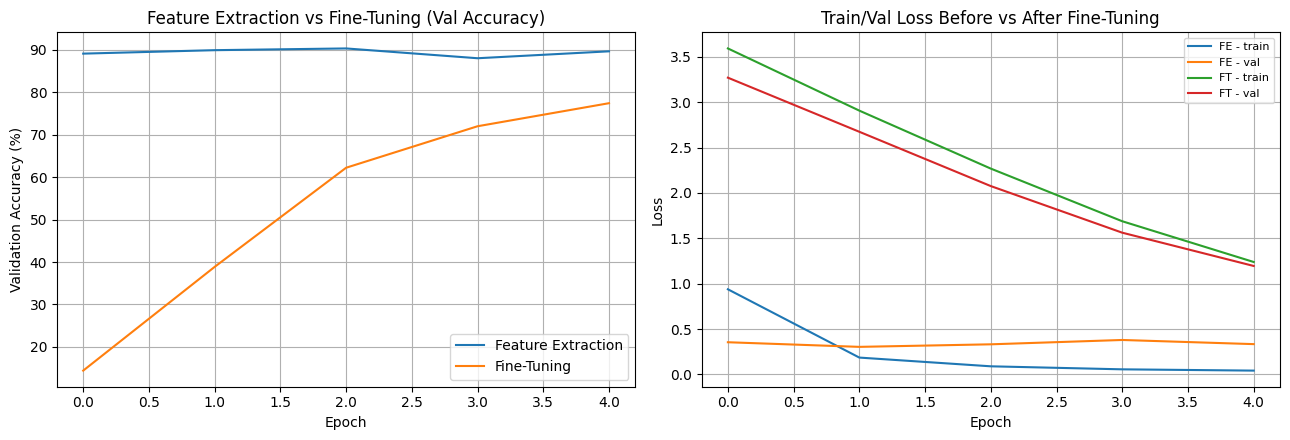

0

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(np.array(hist_fe.history["val_accuracy"]) * 100, label="Feature Extraction")
ax[0].plot(np.array(hist_ft.history["val_accuracy"]) * 100, label="Fine-Tuning")
ax[0].set_title("Feature Extraction vs Fine-Tuning (Val Accuracy)")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Validation Accuracy (%)"); ax[0].legend(); ax[0].grid(True)

ax[1].plot(hist_fe.history["loss"], label="FE - train")
ax[1].plot(hist_fe.history["val_loss"], label="FE - val")
ax[1].plot(hist_ft.history["loss"], label="FT - train")
ax[1].plot(hist_ft.history["val_loss"], label="FT - val")
ax[1].set_title("Train/Val Loss Before vs After Fine-Tuning")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Loss"); ax[1].legend(fontsize=8); ax[1].grid(True)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/plot11_12_transfer_learning.png", dpi=200, bbox_inches="tight")
plt.show()

del fe_model, ft_model
tf.keras.backend.clear_session(); gc.collect()


In [ ]:
full_train_prepped = raw_train.map(prep, num_parallel_calls=tf.data.AUTOTUNE)

X_pool, y_pool = [], []
for img, lbl in full_train_prepped.as_numpy_iterator():
    X_pool.append(img)
    y_pool.append(lbl)

X_pool = np.array(X_pool, dtype=np.float32)
y_pool = np.array(y_pool)
print("Pool shapes:", X_pool.shape, y_pool.shape)
print(f"Approx. memory footprint: {X_pool.nbytes / 1e9:.2f} GB")


Pool shapes: (3680, 224, 224, 3) (3680,)
Approx. memory footprint: 2.22 GB


In [ ]:
def build_candidate(cfg):
    inp, feat, _ = mobilenet_backbone()
    x = layers.Dense(
        256, activation="relu",
        kernel_initializer=cfg.get("init", "glorot_uniform"),
        kernel_regularizer=l2(cfg["l2"]) if cfg.get("l2", 0) > 0 else None,
    )(feat)
    if cfg.get("dropout", 0) > 0:
        x = layers.Dropout(cfg["dropout"])(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=cfg.get("lr", 0.001)),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

candidate_configs = {
    "C1": dict(init="he_normal",dropout=0.0, l2=0.00, lr=0.001),
    "C2": dict(init="he_normal",dropout=0.4, l2=0.00, lr=0.001),
    "C3": dict(init="he_normal",dropout=0.0, l2=0.02, lr=0.001),
    "C4": dict(init="glorot_uniform", dropout=0.25, l2=0.00, lr=0.0001),
}


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=7)
cv_scores = {}

for tag, cfg in candidate_configs.items():
    print("Evaluating configuration:", tag)
    fold_accs = []
    for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(X_pool), start=1):
        print(f"  fold {fold_idx}/5")
        Xtr, ytr = X_pool[tr_idx], y_pool[tr_idx]
        Xva, yva = X_pool[va_idx], y_pool[va_idx]

        model = build_candidate(cfg)
        model.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=5, batch_size=32, verbose=0)
        _, acc = model.evaluate(Xva, yva, verbose=0)
        fold_accs.append(acc * 100)

        del model, Xtr, ytr, Xva, yva
        tf.keras.backend.clear_session(); gc.collect()

    cv_scores[tag] = fold_accs


Evaluating configuration: C1
  fold 1/5
  fold 2/5
  fold 3/5
  fold 4/5
  fold 5/5
Evaluating configuration: C2
  fold 1/5
  fold 2/5
  fold 3/5
  fold 4/5
  fold 5/5
Evaluating configuration: C3
  fold 1/5
  fold 2/5
  fold 3/5
  fold 4/5
  fold 5/5
Evaluating configuration: C4
  fold 1/5
  fold 2/5
  fold 3/5
  fold 4/5
  fold 5/5


Config | Mean   | SD    | Per-fold
C1     | 90.62% | 0.52 | [91.2, 90.9, 90.2, 91.0, 89.8]
C2     | 90.87% | 0.66 | [91.3, 91.3, 90.6, 91.4, 89.7]
C3     | 87.88% | 1.44 | [89.4, 86.1, 89.4, 88.2, 86.3]
C4     | 89.27% | 0.36 | [89.3, 88.9, 89.9, 89.1, 89.1]


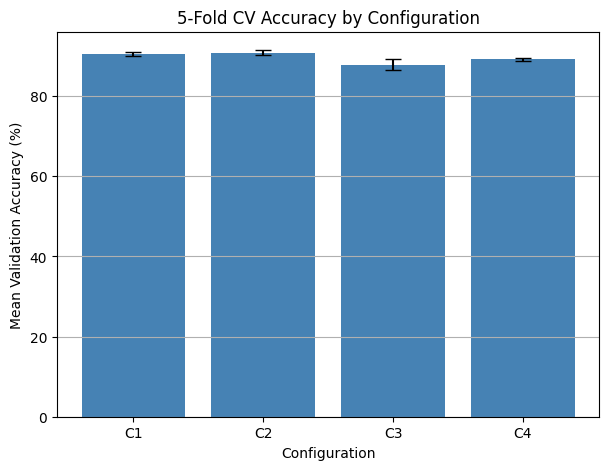

In [ ]:
print(f"{'Config':6s} | {'Mean':6s} | {'SD':5s} | Per-fold")
for tag, accs in cv_scores.items():
    print(f"{tag:6s} | {np.mean(accs):5.2f}% | {np.std(accs):4.2f} | {[round(a,1) for a in accs]}")

plt.figure(figsize=(7, 5))
tags = list(cv_scores.keys())
means = [np.mean(cv_scores[t]) for t in tags]
sds = [np.std(cv_scores[t]) for t in tags]
plt.bar(tags, means, yerr=sds, capsize=6, color="steelblue")
plt.title("5-Fold CV Accuracy by Configuration")
plt.xlabel("Configuration"); plt.ylabel("Mean Validation Accuracy (%)")
plt.grid(True, axis="y")
plt.savefig(f"{OUT_DIR}/plot13_cv_accuracy.png", dpi=200, bbox_inches="tight")
plt.show()


In [ ]:
best_tag = max(cv_scores, key=lambda t: np.mean(cv_scores[t]))
best_cfg = candidate_configs[best_tag]
print("Selected configuration:", best_tag, best_cfg)

final_model = build_candidate(best_cfg)
t0 = time.time()
final_model.fit(X_pool, y_pool, epochs=5, batch_size=32, verbose=1)
train_time = time.time() - t0

X_test, y_test = [], []
for img, lbl in test_ds.as_numpy_iterator():
    X_test.append(img)
    y_test.append(lbl)
X_test = np.array(X_test, dtype=np.float32)
y_test = np.array(y_test)
print("Test set shape:", X_test.shape)


Selected configuration: C2 {'init': 'he_normal', 'dropout': 0.4, 'l2': 0.0, 'lr': 0.001}
Epoch 1/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.6927 - loss: 1.1021
Epoch 2/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8997 - loss: 0.3180
Epoch 3/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9323 - loss: 0.2115
Epoch 4/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9459 - loss: 0.1627
Epoch 5/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9633 - loss: 0.1184
Test set shape: (3669, 224, 224, 3)


In [ ]:
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=0)
y_prob = final_model.predict(X_test)
y_hat = np.argmax(y_prob, axis=1)

prec = precision_score(y_test, y_hat, average="macro", zero_division=0)
rec = recall_score(y_test, y_hat, average="macro", zero_division=0)
f1 = f1_score(y_test, y_hat, average="macro", zero_division=0)
n_params = final_model.count_params()
mean_cv = np.mean(cv_scores[best_tag])
sd_cv = np.std(cv_scores[best_tag])

print(f"Mean CV Accuracy  : {mean_cv:.2f}%")
print(f"CV Std. Dev.      : {sd_cv:.2f}")
print(f"Test Accuracy     : {test_acc*100:.2f}%")
print(f"Precision (macro) : {prec:.4f}")
print(f"Recall (macro)    : {rec:.4f}")
print(f"F1-score (macro)  : {f1:.4f}")
print(f"Training Time (s) : {train_time:.1f}")
print(f"Total Parameters  : {n_params:,}")


2026-08-30 10:22:16.080695: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 10:22:16.227483: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 10:22:16.366805: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


115/115 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step
Mean CV Accuracy  : 90.87%
CV Std. Dev.      : 0.66
Test Accuracy     : 89.15%
Precision (macro) : 0.8969
Recall (macro)    : 0.8911
F1-score (macro)  : 0.8904
Training Time (s) : 30.7
Total Parameters  : 2,595,429


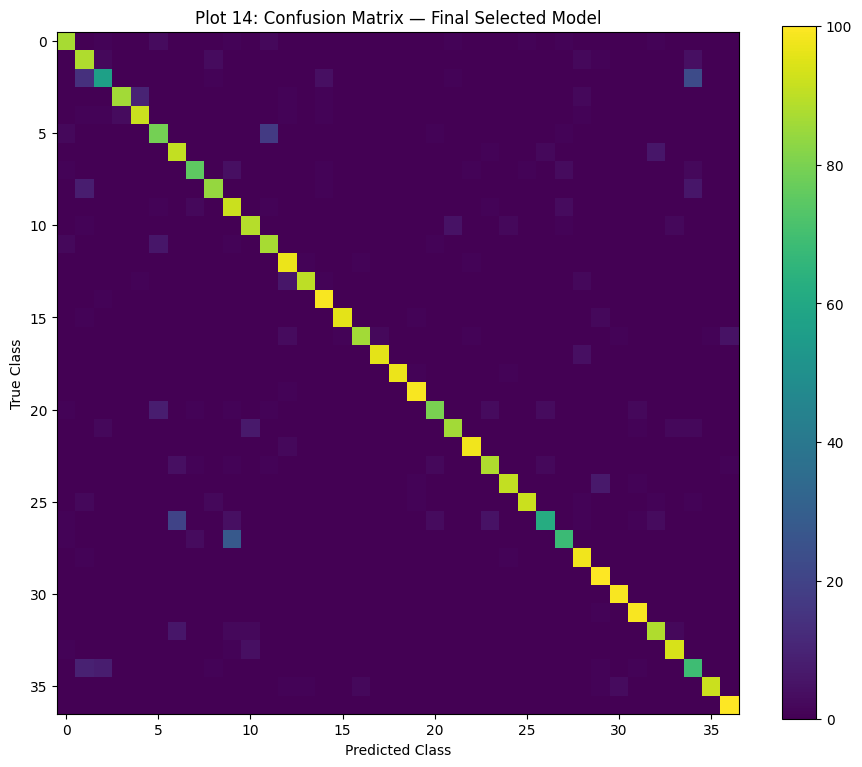

In [ ]:
cm = confusion_matrix(y_test, y_hat)

plt.figure(figsize=(11, 9))
plt.imshow(cm, cmap="viridis")
plt.title("Plot 14: Confusion Matrix — Final Selected Model")
plt.xlabel("Predicted Class"); plt.ylabel("True Class")
plt.colorbar()
plt.savefig(f"{OUT_DIR}/plot14_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()


In [ ]:
def build_row_model(row_cfg):

    unfreeze_n = row_cfg.get("unfreeze_last_n", 0)

    backbone = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
    if unfreeze_n > 0:
        backbone.trainable = True
        for layer in backbone.layers[:-unfreeze_n]:
            layer.trainable = False
    else:
        backbone.trainable = False

    inp = layers.Input(shape=(224, 224, 3))
    x = backbone(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(
        256, activation="relu",
        kernel_initializer=row_cfg.get("init", "glorot_uniform"),
        kernel_regularizer=l2(row_cfg["l2"]) if row_cfg.get("l2", 0) > 0 else None,
    )(x)
    if row_cfg.get("dropout", 0) > 0:
        x = layers.Dropout(row_cfg["dropout"])(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = models.Model(inp, out)

    lr = row_cfg.get("lr", 0.001)
    opt_name = row_cfg.get("optimizer", "adam")
    if opt_name == "sgd":
        opt = tf.keras.optimizers.SGD(learning_rate=lr, momentum=row_cfg.get("momentum", 0.0))
    elif opt_name == "rmsprop":
        opt = tf.keras.optimizers.RMSprop(learning_rate=lr)
    else:
        opt = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


In [ ]:
# --- Identify the "best" setting from each earlier experiment ---
best_init_tag = max(init_histories, key=lambda t: init_histories[t]["val_accuracy"][-1])
best_reg_tag = max(reg_histories, key=lambda t: reg_histories[t]["val_accuracy"][-1])
best_optim_tag = max(optim_histories, key=lambda t: optim_histories[t]["val_accuracy"][-1])
best_lr = max(lr_scores, key=lr_scores.get)
best_bs = max(bs_scores, key=bs_scores.get)
best_dropout = max(dropout_scores, key=dropout_scores.get)

print("Best initialization :", best_init_tag)
print("Best regularization  :", best_reg_tag)
print("Best optimizer        :", best_optim_tag)
print("Best learning rate    :", best_lr)
print("Best batch size        :", best_bs)
print("Best dropout rate      :", best_dropout)

optimizer_lookup = {
    "SGD": dict(optimizer="sgd", lr=0.01),
    "Momentum": dict(optimizer="sgd", lr=0.01, momentum=0.9),
    "RMSProp": dict(optimizer="rmsprop", lr=0.001),
    "Adam": dict(optimizer="adam", lr=0.0005),
}
reg_lookup = {
    "No Regularization": dict(dropout=0.0, l2=0.0),
    "L2 Only":            dict(dropout=0.0, l2=0.02),
    "Dropout Only":       dict(dropout=0.4, l2=0.0),
    "Dropout + L2":       dict(dropout=0.4, l2=0.02),
}
init_lookup = {
    "Zero": "zeros", "Random": "random_normal",
    "Xavier": "glorot_uniform", "He": "he_normal", "LeCun": "lecun_normal",
}

overall_configs = {
    "Baseline":            dict(init="glorot_uniform", dropout=0.0, l2=0.0, optimizer="adam", lr=0.001),
    "Best Initialization": dict(init=init_lookup[best_init_tag], dropout=0.0, l2=0.0, optimizer="adam", lr=0.001),
    "Best Regularization": dict(init="glorot_uniform", optimizer="adam", lr=0.001, **reg_lookup[best_reg_tag]),
    "Best Optimizer":      dict(init="glorot_uniform", dropout=0.0, l2=0.0, **optimizer_lookup[best_optim_tag]),
    "Best Hyperparameters":dict(init="glorot_uniform", dropout=best_dropout, l2=0.0, optimizer="adam", lr=best_lr, batch_size=best_bs),
    "Fine-Tuned Model":    dict(init="glorot_uniform", dropout=0.0, l2=0.0, optimizer="adam", lr=1e-5, unfreeze_last_n=40),
}
for tag, cfg in overall_configs.items():
    print(tag, "->", cfg)


Best initialization : He
Best regularization  : Dropout Only
Best optimizer        : Momentum
Best learning rate    : 0.001
Best batch size        : 64
Best dropout rate      : 0.5
Baseline -> {'init': 'glorot_uniform', 'dropout': 0.0, 'l2': 0.0, 'optimizer': 'adam', 'lr': 0.001}
Best Initialization -> {'init': 'he_normal', 'dropout': 0.0, 'l2': 0.0, 'optimizer': 'adam', 'lr': 0.001}
Best Regularization -> {'init': 'glorot_uniform', 'optimizer': 'adam', 'lr': 0.001, 'dropout': 0.4, 'l2': 0.0}
Best Optimizer -> {'init': 'glorot_uniform', 'dropout': 0.0, 'l2': 0.0, 'optimizer': 'sgd', 'lr': 0.01, 'momentum': 0.9}
Best Hyperparameters -> {'init': 'glorot_uniform', 'dropout': 0.5, 'l2': 0.0, 'optimizer': 'adam', 'lr': 0.001, 'batch_size': 64}
Fine-Tuned Model -> {'init': 'glorot_uniform', 'dropout': 0.0, 'l2': 0.0, 'optimizer': 'adam', 'lr': 1e-05, 'unfreeze_last_n': 40}


In [ ]:
overall_results = {}

for row_name, row_cfg in overall_configs.items():
    print("=" * 60)
    print("Overall Results row:", row_name)
    batch_size = row_cfg.get("batch_size", 32)

    # --- 5-fold CV on the training pool ---
    fold_accs = []
    for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(X_pool), start=1):
        print(f"  fold {fold_idx}/5")
        Xtr, ytr = X_pool[tr_idx], y_pool[tr_idx]
        Xva, yva = X_pool[va_idx], y_pool[va_idx]
        model = build_row_model(row_cfg)
        model.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=5, batch_size=batch_size, verbose=0)
        _, acc = model.evaluate(Xva, yva, verbose=0)
        fold_accs.append(acc * 100)
        del model, Xtr, ytr, Xva, yva
        tf.keras.backend.clear_session(); gc.collect()

    cv_mean = np.mean(fold_accs)
    cv_sd = np.std(fold_accs)

    # --- Retrain on the full pool, evaluate on the untouched test set ---
    model = build_row_model(row_cfg)
    t0 = time.time()
    model.fit(X_pool, y_pool, epochs=5, batch_size=batch_size, verbose=0)
    row_train_time = time.time() - t0
    _, row_test_acc = model.evaluate(X_test, y_test, verbose=0)

    overall_results[row_name] = {
        "cv_mean": cv_mean,
        "cv_sd": cv_sd,
        "test_acc": row_test_acc * 100,
        "train_time": row_train_time,
    }

    del model
    tf.keras.backend.clear_session(); gc.collect()


Overall Results row: Baseline
  fold 1/5
  fold 2/5
  fold 3/5
  fold 4/5
  fold 5/5
Overall Results row: Best Initialization
  fold 1/5
  fold 2/5
  fold 3/5
  fold 4/5
  fold 5/5
Overall Results row: Best Regularization
  fold 1/5
  fold 2/5
  fold 3/5
  fold 4/5
  fold 5/5
Overall Results row: Best Optimizer
  fold 1/5
  fold 2/5
  fold 3/5
  fold 4/5
  fold 5/5
Overall Results row: Best Hyperparameters
  fold 1/5
  fold 2/5
  fold 3/5
  fold 4/5
  fold 5/5
Overall Results row: Fine-Tuned Model
  fold 1/5
  fold 2/5
  fold 3/5
  fold 4/5
  fold 5/5


Configuration          | CV Accuracy | SD    | Test Accuracy | Training Time
Baseline               |      90.84% | 0.71 |        89.02% |        29.2s
Best Initialization    |      90.41% | 0.41 |        87.84% |        29.4s
Best Regularization    |      90.63% | 0.99 |        88.50% |        30.0s
Best Optimizer         |      90.60% | 0.60 |        88.03% |        28.9s
Best Hyperparameters   |      91.03% | 0.84 |        90.08% |        33.2s
Fine-Tuned Model       |      78.21% | 1.33 |        81.25% |        43.0s


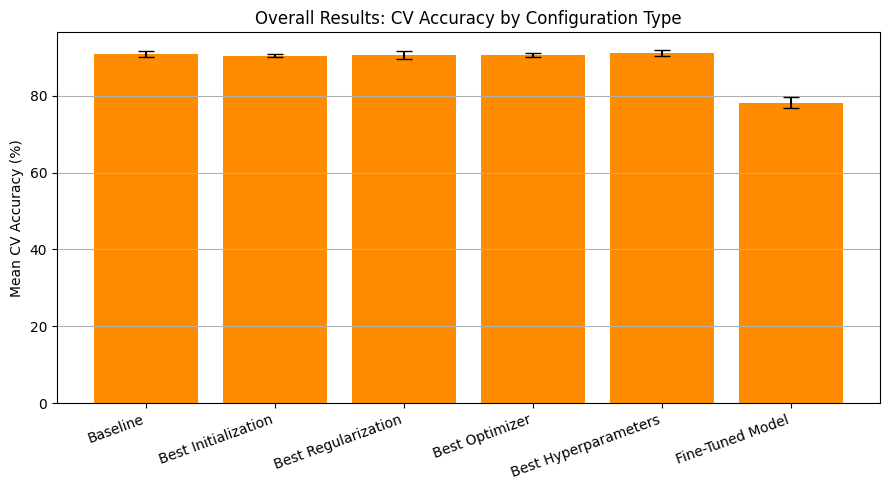

In [ ]:
print(f"{'Configuration':22s} | {'CV Accuracy':11s} | {'SD':5s} | {'Test Accuracy':13s} | {'Training Time':13s}")
for row_name, r in overall_results.items():
    print(f"{row_name:22s} | {r['cv_mean']:10.2f}% | {r['cv_sd']:4.2f} | {r['test_acc']:12.2f}% | {r['train_time']:11.1f}s")

plt.figure(figsize=(9, 5))
names = list(overall_results.keys())
means = [overall_results[n]["cv_mean"] for n in names]
sds = [overall_results[n]["cv_sd"] for n in names]
plt.bar(names, means, yerr=sds, capsize=6, color="darkorange")
plt.title("Overall Results: CV Accuracy by Configuration Type")
plt.ylabel("Mean CV Accuracy (%)")
plt.xticks(rotation=20, ha="right")
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/overall_results_summary.png", dpi=200, bbox_inches="tight")
plt.show()


In [ ]:
extra_configs = {
    "E1": dict(init="he_normal", dropout=0.3, l2=0.01, lr=0.0005),
    "E2": dict(init="glorot_uniform", dropout=0.5, l2=0.00, lr=0.001),
}

for tag, cfg in extra_configs.items():
    print("Evaluating extra configuration:", tag)
    fold_accs = []
    for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(X_pool), start=1):
        Xtr, ytr = X_pool[tr_idx], y_pool[tr_idx]
        Xva, yva = X_pool[va_idx], y_pool[va_idx]
        model = build_candidate(cfg)
        model.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=5, batch_size=32, verbose=0)
        _, acc = model.evaluate(Xva, yva, verbose=0)
        fold_accs.append(acc * 100)
        del model, Xtr, ytr, Xva, yva
        tf.keras.backend.clear_session(); gc.collect()
    cv_scores[tag] = fold_accs
    print(f"  {tag}: mean={np.mean(fold_accs):.2f}%  sd={np.std(fold_accs):.2f}")

print("\nFinal comparison including extra configurations:")
for tag, accs in cv_scores.items():
    print(f"{tag:6s} | mean={np.mean(accs):5.2f}% | sd={np.std(accs):4.2f}")


Evaluating extra configuration: E1
  E1: mean=90.46%  sd=0.61
Evaluating extra configuration: E2
